# Part B: Revenue Analysis - Financial Adjustment

## Imports + paths

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

p = Path.cwd().resolve()
for parent in [p] + list(p.parents):
    if (parent / "src" / "config.py").exists():
        sys.path.insert(0, str(parent))
        break

from src.config import (
    FIN_TABLE_PATH, FIN_FINAL_PATH, FIN_FINAL_CSV_PATH,
    FIG_DIR, M1_PATH, M2_PATH,
    DUCKDB_THREADS, DUCKDB_MEMORY
)
from src.duckdb_utils import connect_duckdb

con = connect_duckdb(DUCKDB_THREADS, DUCKDB_MEMORY)

FIN_IN = FIN_TABLE_PATH
print("FIN_IN:", FIN_IN)
print("FIG_DIR:", FIG_DIR)

FIN_IN: D:\Entity Resolution and Revenue Modeling\outputs\financial_table.parquet
FIG_DIR: D:\Entity Resolution and Revenue Modeling\outputs\figures


## Schema + quick counts

In [2]:
display(con.execute(f"DESCRIBE SELECT * FROM read_parquet('{FIN_IN.as_posix()}')").df())

status = con.execute(f"""
SELECT
  COALESCE(match_status, 'unmatched') AS match_status,
  COUNT(*) AS n,
  SUM(matched_location_id IS NOT NULL) AS has_matched_location_id,
  ROUND(100.0 * SUM(matched_location_id IS NOT NULL) / COUNT(*), 2) AS pct_has_id
FROM read_parquet('{FIN_IN.as_posix()}')
GROUP BY 1
ORDER BY n DESC
""").df()
display(status)


,column_name,column_type,null,key,default,extra
0,raw_id,VARCHAR,YES,None,None,None
1,matched_location_id,VARCHAR,YES,None,None,None
2,business_entity_id,VARCHAR,YES,None,None,None
3,area_sq_ft,BIGINT,YES,None,None,None
4,name,VARCHAR,YES,None,None,None
5,address,VARCHAR,YES,None,None,None
6,city,VARCHAR,YES,None,None,None
7,state,VARCHAR,YES,None,None,None
8,postal_code,VARCHAR,YES,None,None,None
9,start_date,DATE,YES,None,None,None


,match_status,n,has_matched_location_id,pct_has_id
0,match,4700545,4700545.0,100.0
1,possible,99303,99303.0,100.0
2,no_match,25524,0.0,0.0


## Analysis base view

In [3]:
con.execute(f"""
CREATE OR REPLACE TEMP VIEW fin_base AS
SELECT *
FROM read_parquet('{FIN_IN.as_posix()}')
WHERE match_status IN ('match','possible')
  AND matched_location_id IS NOT NULL
  AND raw_card_revenue IS NOT NULL
  AND raw_card_revenue >= 0
  AND days_in_window IS NOT NULL AND days_in_window > 0
""")

display(con.execute("""
SELECT
  COUNT(*) AS n_rows,
  COUNT(DISTINCT matched_location_id) AS n_locations,
  COUNT(DISTINCT business_entity_id) AS n_entities,
  MIN(start_date) AS min_start,
  MAX(end_date) AS max_end,
  MIN(raw_card_revenue) AS min_rev,
  MAX(raw_card_revenue) AS max_rev
FROM fin_base
""").df())


,n_rows,n_locations,n_entities,min_start,max_end,min_rev,max_rev
0,4796267,148574,100,2022-01-01,2024-12-31,0.01,7880772.78


## Segmentation features using business_entity_id and area_sq_ft

In [4]:
con.execute("""
CREATE OR REPLACE TEMP VIEW entity_sizes AS
SELECT
  business_entity_id,
  COUNT(DISTINCT matched_location_id) AS entity_location_count
FROM fin_base
WHERE business_entity_id IS NOT NULL
GROUP BY 1
""")

con.execute("""
CREATE OR REPLACE TEMP VIEW fin_feat AS
WITH base AS (
  SELECT
    f.*,
    COALESCE(es.entity_location_count, 1) AS entity_location_count,
    CASE WHEN area_sq_ft IS NULL THEN NULL
         WHEN area_sq_ft < 1500 THEN 'S'
         WHEN area_sq_ft < 4000 THEN 'M'
         WHEN area_sq_ft < 10000 THEN 'L'
         ELSE 'XL' END AS sqft_bucket
  FROM fin_base f
  LEFT JOIN entity_sizes es
    ON f.business_entity_id = es.business_entity_id
)
SELECT
  *,
  (card_rev_per_day / NULLIF(area_sq_ft, 0)) AS card_rev_per_day_per_sqft
FROM base
""")

display(con.execute("""
SELECT sqft_bucket, COUNT(*) AS n_rows
FROM fin_feat
GROUP BY 1
ORDER BY n_rows DESC
""").df())


,sqft_bucket,n_rows
0,L,3037828
1,M,1254892
2,S,503547


## (Model 1): Global multiplier with sensitivity

In [5]:
con.execute("""
CREATE OR REPLACE TEMP VIEW fin_m1 AS
SELECT
  *,
  0.60 AS p_card_60, (1.0/0.60) AS mult_60, raw_card_revenue*(1.0/0.60) AS adjusted_rev_m1_60,
  0.65 AS p_card_65, (1.0/0.65) AS mult_65, raw_card_revenue*(1.0/0.65) AS adjusted_rev_m1_65,
  0.70 AS p_card_70, (1.0/0.70) AS mult_70, raw_card_revenue*(1.0/0.70) AS adjusted_rev_m1_70
FROM fin_feat
""")

display(con.execute("""
SELECT
  approx_quantile(raw_card_revenue, 0.50) AS median_raw,
  approx_quantile(adjusted_rev_m1_65, 0.50) AS median_adj_m1_65,
  approx_quantile(raw_card_revenue, 0.99) AS q99_raw,
  approx_quantile(adjusted_rev_m1_65, 0.99) AS q99_adj_m1_65,
  MAX(raw_card_revenue) AS max_raw,
  MAX(adjusted_rev_m1_65) AS max_adj_m1_65
FROM fin_m1
""").df())


,median_raw,median_adj_m1_65,q99_raw,q99_adj_m1_65,max_raw,max_adj_m1_65
0,16883.481234,25974.586514,337532.435966,519280.670717,7880772.78,1.212427e+07


## (Model 2): Segmented multiplier with shrinkage and log-ratio mapping

In [6]:
P0 = 0.65
ALPHA = 0.08
PRIOR_N = 500
P_MIN, P_MAX = 0.50, 0.90

con.execute(f"""
CREATE OR REPLACE TEMP VIEW fin_m2 AS
WITH overall AS (
  SELECT AVG(card_rev_per_day_per_sqft) AS overall_avg
  FROM fin_feat
  WHERE card_rev_per_day_per_sqft IS NOT NULL
),
seg AS (
  SELECT
    business_entity_id,
    sqft_bucket,
    COUNT(*) AS n,
    AVG(card_rev_per_day_per_sqft) AS avg_card_intensity
  FROM fin_feat
  WHERE business_entity_id IS NOT NULL
    AND sqft_bucket IS NOT NULL
    AND card_rev_per_day_per_sqft IS NOT NULL
  GROUP BY 1,2
),
seg_ratio AS (
  SELECT
    s.business_entity_id,
    s.sqft_bucket,
    s.n,
    ((s.n * (s.avg_card_intensity / o.overall_avg)) + ({PRIOR_N} * 1.0)) / (s.n + {PRIOR_N}) AS ratio_shrunk
  FROM seg s
  CROSS JOIN overall o
),
seg_p AS (
  SELECT
    business_entity_id,
    sqft_bucket,
    LEAST({P_MAX}, GREATEST({P_MIN}, {P0} + ({ALPHA}) * ln(ratio_shrunk))) AS p_card_m2
  FROM seg_ratio
)
SELECT
  m1.*,
  sp.p_card_m2,
  (1.0 / sp.p_card_m2) AS mult_m2,
  raw_card_revenue * (1.0 / sp.p_card_m2) AS adjusted_rev_m2
FROM fin_m1 m1
LEFT JOIN seg_p sp
  ON m1.business_entity_id = sp.business_entity_id
 AND m1.sqft_bucket = sp.sqft_bucket
""")

display(con.execute("""
SELECT
  MIN(p_card_m2) AS min_p_card,
  approx_quantile(p_card_m2, 0.05) AS q05_p_card,
  approx_quantile(p_card_m2, 0.50) AS median_p_card,
  approx_quantile(p_card_m2, 0.95) AS q95_p_card,
  MAX(p_card_m2) AS max_p_card,
  MIN(mult_m2) AS min_mult,
  approx_quantile(mult_m2, 0.50) AS median_mult,
  MAX(mult_m2) AS max_mult
FROM fin_m2
""").df())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_p_card,q05_p_card,median_p_card,q95_p_card,max_p_card,min_mult,median_mult,max_mult
0,0.5,0.505203,0.603773,0.739404,0.842733,1.186615,1.655876,2.0


## Diagnostics: multiplier ratios, outliers, within-entity stability

In [7]:
con.execute("""
CREATE OR REPLACE TEMP VIEW fin_compare AS
SELECT
  *,
  (1.0/0.65) AS mult_m1_65,
  (mult_m2 / (1.0/0.65)) AS mult_ratio_m2_vs_m1,
  (adjusted_rev_m1_65 / days_in_window) / NULLIF(area_sq_ft,0) AS adj1_rev_per_day_sqft,
  (adjusted_rev_m2   / days_in_window) / NULLIF(area_sq_ft,0) AS adj2_rev_per_day_sqft
FROM fin_m2
""")

display(con.execute("""
SELECT
  approx_quantile(mult_ratio_m2_vs_m1, 0.01) AS q01_ratio,
  approx_quantile(mult_ratio_m2_vs_m1, 0.50) AS median_ratio,
  approx_quantile(mult_ratio_m2_vs_m1, 0.99) AS q99_ratio,
  MIN(mult_ratio_m2_vs_m1) AS min_ratio,
  MAX(mult_ratio_m2_vs_m1) AS max_ratio
FROM fin_compare
""").df())

display(con.execute("""
WITH q AS (
  SELECT
    approx_quantile(adj1_rev_per_day_sqft, 0.99) AS q99_m1,
    approx_quantile(adj2_rev_per_day_sqft, 0.99) AS q99_m2
  FROM fin_compare
  WHERE area_sq_ft IS NOT NULL AND area_sq_ft > 0
)
SELECT
  ANY_VALUE(q99_m1) AS q99_m1,
  ANY_VALUE(q99_m2) AS q99_m2,
  SUM(CASE WHEN adj1_rev_per_day_sqft > q99_m1 THEN 1 ELSE 0 END) AS outliers_m1,
  SUM(CASE WHEN adj2_rev_per_day_sqft > q99_m2 THEN 1 ELSE 0 END) AS outliers_m2,
  COUNT(*) AS n_rows
FROM fin_compare, q
WHERE area_sq_ft IS NOT NULL AND area_sq_ft > 0
""").df())

display(con.execute("""
SELECT
  business_entity_id,
  COUNT(*) AS n_rows,
  MIN(mult_m2) AS min_mult,
  AVG(mult_m2) AS avg_mult,
  MAX(mult_m2) AS max_mult,
  STDDEV_SAMP(mult_m2) AS std_mult
FROM fin_compare
WHERE business_entity_id IS NOT NULL
GROUP BY 1
ORDER BY std_mult DESC
LIMIT 15
""").df())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,q01_ratio,median_ratio,q99_ratio,min_ratio,max_ratio
0,0.820898,1.076287,1.3,0.7713,1.3


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,q99_m1,q99_m2,outliers_m1,outliers_m2,n_rows
0,6.235821,5.674157,47199.0,47260.0,4796267


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,business_entity_id,n_rows,min_mult,avg_mult,max_mult,std_mult
0,fc377a4c-4a15-444d-85e7-ce8a3a578a8e,59071,1.511464,1.880061,2.000000,0.171254
1,5be6128e-18c2-4797-a142-ea7d17be3111,63923,1.463009,1.796308,1.915157,0.164357
2,93829b43-922f-415a-a1e3-db63ef7ddc76,51845,1.507063,1.839240,1.953930,0.164350
3,5ab33edf-6e59-4ed3-a8b3-17fa18d0752b,77274,1.521300,1.860598,1.978988,0.163796
4,1825bc54-30be-445f-a835-14f2ceb81f9d,67120,1.555058,1.883367,2.000000,0.161285
5,e2acf72f-9e57-4f7a-a0ee-89aed453dd32,70514,1.541057,1.887640,2.000000,0.160497
6,b74d0fb1-32e7-4629-8fad-c1a606cb0fb3,71732,1.522373,1.879300,1.994824,0.159559
7,5fb8d16c-2720-497d-b2eb-d6899be578c7,75446,1.456339,1.789153,1.893412,0.149360
8,a013ac6e-deda-4e16-9b3d-bd5ce9a1fa6f,53170,1.452678,1.790432,1.893272,0.148285
9,134c6c92-ec5b-427c-9fde-4fbf3ff350bf,75372,1.547954,1.900108,2.000000,0.147623


## Sampling for plots and visualisations

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

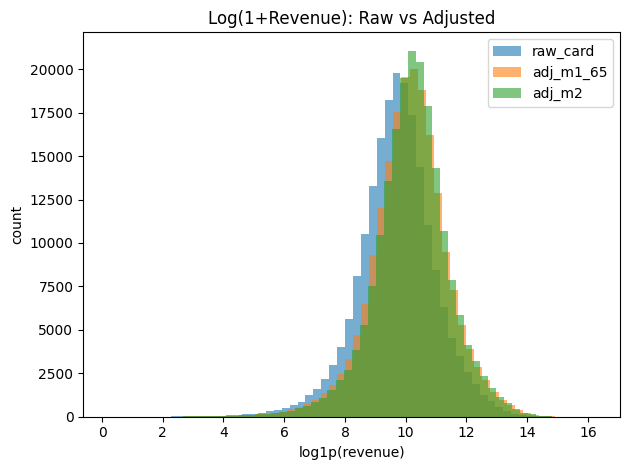

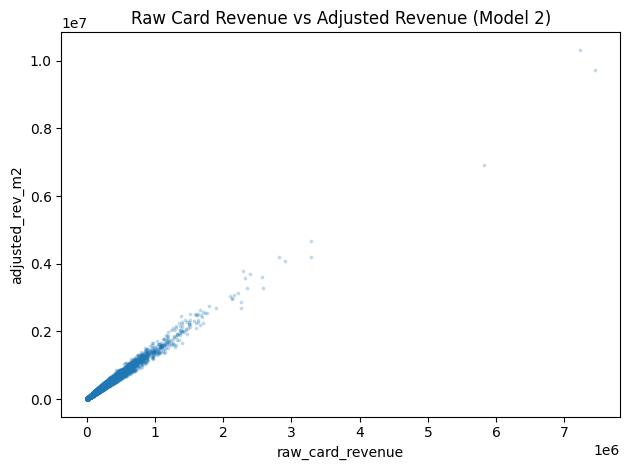

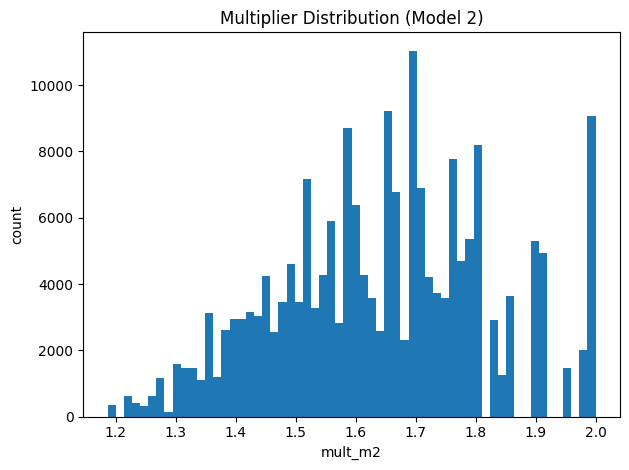

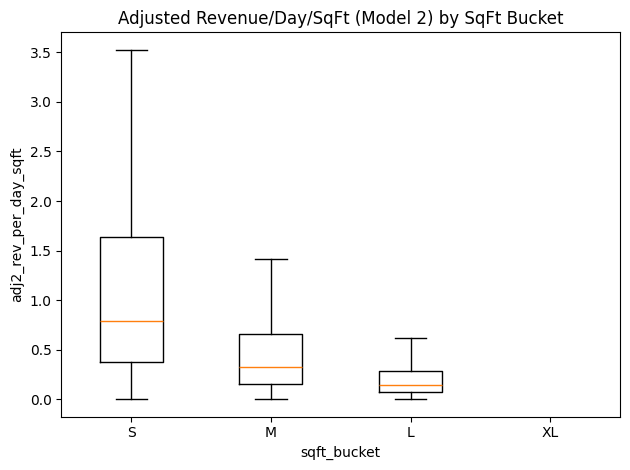

In [8]:
plot_df = con.execute("""
SELECT
  raw_card_revenue,
  adjusted_rev_m1_65,
  adjusted_rev_m2,
  mult_m2,
  area_sq_ft,
  days_in_window,
  adj2_rev_per_day_sqft,
  sqft_bucket
FROM fin_compare
USING SAMPLE 200000 ROWS
""").df()

plt.figure()
plt.hist(np.log1p(plot_df["raw_card_revenue"]), bins=60, alpha=0.6, label="raw_card")
plt.hist(np.log1p(plot_df["adjusted_rev_m1_65"]), bins=60, alpha=0.6, label="adj_m1_65")
plt.hist(np.log1p(plot_df["adjusted_rev_m2"]), bins=60, alpha=0.6, label="adj_m2")
plt.legend()
plt.title("Log(1+Revenue): Raw vs Adjusted")
plt.xlabel("log1p(revenue)")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(FIG_DIR / "hist_raw_vs_adjusted_log.png", dpi=200)
plt.show()
plt.close()

plt.figure()
plt.scatter(plot_df["raw_card_revenue"], plot_df["adjusted_rev_m2"], s=3, alpha=0.2)
plt.title("Raw Card Revenue vs Adjusted Revenue (Model 2)")
plt.xlabel("raw_card_revenue")
plt.ylabel("adjusted_rev_m2")
plt.tight_layout()
plt.savefig(FIG_DIR / "scatter_raw_vs_adj_m2.png", dpi=200)
plt.show()
plt.close()

plt.figure()
plt.hist(plot_df["mult_m2"], bins=60)
plt.title("Multiplier Distribution (Model 2)")
plt.xlabel("mult_m2")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(FIG_DIR / "mult_m2_distribution.png", dpi=200)
plt.show()
plt.close()

plt.figure()
data = [plot_df.loc[plot_df["sqft_bucket"]==b, "adj2_rev_per_day_sqft"].dropna().values for b in ["S","M","L","XL"]]
plt.boxplot(data, tick_labels=["S","M","L","XL"], showfliers=False)
plt.title("Adjusted Revenue/Day/SqFt (Model 2) by SqFt Bucket")
plt.xlabel("sqft_bucket")
plt.ylabel("adj2_rev_per_day_sqft")
plt.tight_layout()
plt.savefig(FIG_DIR / "box_adj2_rev_per_day_sqft_by_bucket.png", dpi=200)
plt.show()
plt.close()


## Export final table with both models

In [9]:
con.execute(f"""
COPY (
  SELECT
    raw_id,
    matched_location_id AS location_id,
    business_entity_id,
    area_sq_ft,
    name,
    address,
    city,
    state,
    postal_code,
    start_date,
    end_date,
    days_in_window,
    raw_card_revenue,
    0.65 AS p_card_m1,
    (1.0/0.65) AS mult_m1,
    adjusted_rev_m1_65 AS adjusted_revenue_m1,
    p_card_m2,
    mult_m2,
    adjusted_rev_m2 AS adjusted_revenue_m2,
    match_status,
    match_source,
    final_score,
    second_score,
    gap
  FROM fin_compare
) TO '{FIN_FINAL_PATH.as_posix()}' (FORMAT PARQUET);
""")

con.execute(f"""
COPY (SELECT * FROM read_parquet('{FIN_FINAL_PATH.as_posix()}'))
TO '{FIN_FINAL_CSV_PATH.as_posix()}'
(HEADER, DELIMITER ',');
""")

print("saved parquet:", FIN_FINAL_PATH)
print("saved CSV:", FIN_FINAL_CSV_PATH)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

saved parquet: D:\Entity Resolution and Revenue Modeling\outputs\financial_table_final.parquet
saved CSV: D:\Entity Resolution and Revenue Modeling\outputs\financial_table_final.csv
